## CASE STUDY 11: LOAN APPROVAL PREDICTION

### Predict whether a loan application should be approved or rejected based on applicant details.

### OBJECTIVE

### The objective of this case study is to develop a machine learning model that predicts whether a loan application should be approved or rejected based on applicant details such as income, credit history, and employment status. 
   

### IMPORT LIBRARIES

### In this step, we import all necessary Python libraries required for data handling, preprocessing, model building, and evaluation.
### Libraries Used
- pandas → Used for handling structured data
- numpy → Used for numerical computations
- seaborn & matplotlib → Used for visualization
- sklearn → Used for machine learning tasks

In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

#### Suppresses warnings for clean output.

In [24]:
import warnings
warnings.filterwarnings("ignore")

### LOAD DATASET

#### Loads dataset and displays initial records.

In [25]:
df = pd.read_csv("loan_data.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP100000,Male,Yes,1,Graduate,Yes,31938,1433,619,120,0.0,Rural,Y
1,LP100001,Male,No,3+,Not Graduate,No,25474,10583,162,120,0.0,Semiurban,N
2,LP100002,Male,No,2,Not Graduate,No,25141,5050,255,180,1.0,Semiurban,Y
3,LP100003,Male,Yes,3+,Not Graduate,Yes,10639,12206,653,180,1.0,Semiurban,Y
4,LP100004,Female,Yes,3+,Graduate,No,12274,9557,548,360,1.0,Urban,Y


### DATA UNDERSTANDING

#### The dataset is analyzed using:
- df.head()
- df.info()
- df.describe()
- df.isnull().sum()
#### This helps identify missing values, understand data types, and analyze data distribution.

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            10000 non-null  object 
 1   Gender             10000 non-null  object 
 2   Married            10000 non-null  object 
 3   Dependents         10000 non-null  object 
 4   Education          10000 non-null  object 
 5   Self_Employed      10000 non-null  object 
 6   ApplicantIncome    10000 non-null  int64  
 7   CoapplicantIncome  10000 non-null  int64  
 8   LoanAmount         10000 non-null  int64  
 9   Loan_Amount_Term   10000 non-null  int64  
 10  Credit_History     8999 non-null   float64
 11  Property_Area      10000 non-null  object 
 12  Loan_Status        10000 non-null  object 
dtypes: float64(1), int64(4), object(8)
memory usage: 1015.8+ KB


In [27]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,10000.000000,10000.000000,10000.000000,10000.000000,8999.000000
mean,25514.712300,14923.831600,375.125100,180.570000,0.502723
std,14158.948783,8723.490204,188.806253,112.223413,0.500020
min,1000.000000,7.000000,50.000000,60.000000,0.000000
25%,13337.750000,7259.250000,210.000000,120.000000,0.000000
50%,25432.000000,14858.000000,376.000000,180.000000,1.000000
75%,37847.500000,22655.250000,538.000000,360.000000,1.000000
max,49998.000000,29997.000000,699.000000,360.000000,1.000000


#### DATA PREPROCESSING

### Handling Missing Values     
### Missing values are handled using:
- Mode for categorical data
- Median for numerical data
### Mode fills frequent values and median reduces the effect of outliers.

In [28]:
print(df.isnull().sum())

Loan_ID                 0
Gender                  0
Married                 0
Dependents              0
Education               0
Self_Employed           0
ApplicantIncome         0
CoapplicantIncome       0
LoanAmount              0
Loan_Amount_Term        0
Credit_History       1001
Property_Area           0
Loan_Status             0
dtype: int64


#### Numerical => filled using median 
#### Since only Credit_History has missing values and it is numerical, we directly filled it using median.

In [39]:
df['Credit_History'].fillna(df['Credit_History'].median(), inplace=True)

In [40]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

### Encoding Categorical Data
#### Categorical values are converted into numerical form using Label Encoding. Machine learning models require numerical input.

In [41]:
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

### FEATURE SELECTION
#### Selects input features and target variable (loan approval status).
- X → Input features
- y → Target variable (Loan_Status)
#### The model learns the relationship between features and output.

In [42]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

In [43]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            10000 non-null  int64  
 1   Gender             10000 non-null  int64  
 2   Married            10000 non-null  int64  
 3   Dependents         10000 non-null  int64  
 4   Education          10000 non-null  int64  
 5   Self_Employed      10000 non-null  int64  
 6   ApplicantIncome    10000 non-null  int64  
 7   CoapplicantIncome  10000 non-null  int64  
 8   LoanAmount         10000 non-null  int64  
 9   Loan_Amount_Term   10000 non-null  int64  
 10  Credit_History     10000 non-null  float64
 11  Property_Area      10000 non-null  int64  
dtypes: float64(1), int64(11)
memory usage: 937.6 KB


In [44]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 10000 entries, 0 to 9999
Series name: Loan_Status
Non-Null Count  Dtype
--------------  -----
10000 non-null  int64
dtypes: int64(1)
memory usage: 78.3 KB


### TRAIN-TEST SPLIT
#### Splits dataset into training and testing sets.
### Dataset is split into:
- Training set (80%)
- Testing set (20%)
### To evaluate model performance on unseen data and avoid overfitting.


In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### MODEL BUILDING
#### Different machine learning models are used:
#### Models Used:
- Logistic Regression
- Decision Tree
- Random Forest
#### Why these models?
### Logistic Regression
#### Used because the target variable (Loan_Status) is binary (0 = Reject, 1 = Approve)
 - Predicts the probability of loan approval (values between 0 and 1)
 - Suitable because features like income and credit history directly influence approval chances
### Decision Tree
#### Used because loan approval follows decision rules similar to real banking logic

#### Example:
- If Credit_History = good → Approve
- If Income low → Reject
#### Captures non-linear relationships in the dataset
#### Easy to understand how decisions are made
### Random Forest
#### Used because the dataset has multiple features and complex patterns

#### Combines multiple decision trees to:
- Improves loan approval prediction accuracy by combining results from multiple trees trained on applicant features like income, credit history, and loan amount
- Reduces overfitting by not relying on a single decision tree, ensuring better generalization across different applicant profiles
#### Handles variations in applicant data better
##### Although Decision Tree and Random Forest may seem similar, Decision Tree builds a single model that is easy to interpret but prone to overfitting, whereas Random Forest combines multiple trees to improve accuracy and reduce overfitting, making it more reliable for this dataset.

### Logistic Regression

In [46]:
l_reg = LogisticRegression(
    max_iter=1000
)
l_reg.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [47]:
y_pred_lr = l_reg.predict(X_test)

#### Decision Tree

In [48]:
dtc = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
)
dtc.fit(X_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [49]:
y_pred_dt = dtc.predict(X_test)

#### Random Forest

In [50]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
)
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [51]:
y_pred_rf = rf.predict(X_test)

#### Multiple models are trained to compare performance.

### MODEL EVALUATION
#### Evaluates model performance using standard metrics.
#### The model is evaluated using:

- Accuracy => Overall correctness
- Precision => Correct approvals
- Recall => Detecting approvals
#### These metrics help measure how well the model performs.

In [52]:
print("Logistic Regression\n")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))

print("\nDecision Tree\n")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))

print("\nRandom Forest\n")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))

Logistic Regression

Accuracy: 0.511
Precision: 0.532319391634981
Recall: 0.40816326530612246

Decision Tree

Accuracy: 0.4945
Precision: 0.5114795918367347
Recall: 0.38969873663751214

Random Forest

Accuracy: 0.5135
Precision: 0.5324074074074074
Recall: 0.44703595724003886


### LOAN PREDICTION
#### Calculates probability of loan approval.
#### The trained model is used to predict loan approval.

#### Instead of directly predicting approval, the model calculates:
-  Probability of approval

In [53]:
import random
i = random.randint(0, len(X_test)-1)
sample = X_test.iloc[i].values.reshape(1, -1)
probability = rf.predict_proba(sample)

approval_prob = probability[0][1]
print("Sample Index:", i)
print("Approval Probability:", approval_prob)

Sample Index: 1118
Approval Probability: 0.4583255829142899


### DECISION USING THRESHOLD
#### Decision is made using threshold (0.5).
#### The final decision is made using a threshold:

-  If probability ≥ 0.5 => Loan Approved 
-  If probability < 0.5 => Loan Rejected 

#### It Ensures decision is not random
#### It is based on probability and risk

#### Real banking systems also use threshold-based decisions

In [54]:
threshold = 0.5
if approval_prob >= threshold:
    print("Loan Approved")
else:
    print("Loan Rejected")

Loan Rejected


### DATA VISUALIZATION
#### Visualizes approval vs rejection distribution.
#### In this step, data visualization is performed to understand the distribution of loan approvals and rejections in the dataset. A count plot is used to represent the number of approved and rejected loan applications.

#### The count plot displays the frequency of each category in the target variable Loan_Status, where:

- 0 represents Rejected loans
- 1 represents Approved loans

#### From the graph, it can be observed that both approved and rejected loans are almost equally distributed in the dataset.

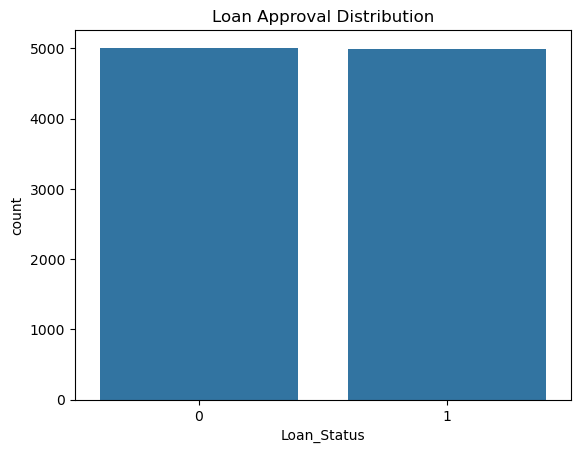

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Approval Distribution")
plt.show()

### CONCLUSION

#### The machine learning model effectively predicts whether a loan application should be approved or rejected based on applicant data.

#### - The decision-making process is not random but based on patterns learned from historical data, ensuring reliable and consistent predictions.

#### - Key factors influencing loan approval include:
    - Income level
    - Credit history
    - Loan amount
    - Employment and financial stability

#### - Among the models used, Random Forest provides better performance due to its ability to handle complex patterns and reduce overfitting.

#### - The system improves efficiency by automating loan approval, reducing manual effort, and minimizing human errors.

#### - It ensures faster processing, better accuracy, and more transparent decision-making in financial systems.

#### - Overall, machine learning-based loan prediction systems play a crucial role in modern banking by enabling data-driven, scalable, and fair decision processes.